In [94]:
import pandas as pd
import scipy.io
import scipy.sparse
import anndata

path = "/home/Data_Drive_8TB/kykim/colon/Public_data/"
sample_list = ['GSM6061645_A001-C-007', 'GSM6061646_A001-C-014', 'GSM6061647_A001-C-023', 'GSM6061648_A001-C-104', 'GSM6061649_A001-C-108', 
               'GSM6061650_A001-C-119', 'GSM6061651_A001-C-124', 'GSM6061652_A001-C-202', 'GSM6061653_A001-C-203', 'GSM6061654_A001-C-207', 
               'GSM6061655_A001-C-223', 'GSM6061656_A002-C-010', 'GSM6061657_A002-C-010-R0', 'GSM6061658_A002-C-016', 'GSM6061659_A002-C-021', 
               'GSM6061660_A002-C-024', 'GSM6061661_A002-C-106', 'GSM6061662_A002-C-114', 'GSM6061663_A002-C-116', 'GSM6061664_A002-C-121', 
               'GSM6061665_A002-C-121-R0', 'GSM6061666_A002-C-201', 'GSM6061667_A002-C-203', 'GSM6061668_A002-C-204', 'GSM6061669_A002-C-205', 
               'GSM6061670_A002-C-212', 'GSM6061671_A008-E-008', 'GSM6061672_A008-E-015', 'GSM6061673_A010-E-018', 'GSM6061674_A010-E-023',
               'GSM6061675_A014-C-001', 'GSM6061676_A014-C-008', 'GSM6061677_A014-C-040', 'GSM6061678_A014-C-043', 'GSM6061679_A014-C-052', 
               'GSM6061680_A014-C-054', 'GSM6061681_A014-C-101', 'GSM6061682_A014-C-108', 'GSM6061683_A014-C-111', 'GSM6061684_A014-C-114', 
               'GSM6061685_A014-C-201', 'GSM6061686_A015-C-001', 'GSM6061687_A015-C-002', 'GSM6061688_A015-C-005', 'GSM6061689_A015-C-006', 
               'GSM6061690_A015-C-008', 'GSM6061691_A015-C-010', 'GSM6061692_A015-C-104', 'GSM6061693_A015-C-106', 'GSM6061694_A015-C-109', 
               'GSM6061695_A015-C-202', 'GSM6061696_A015-C-203', 'GSM6061697_A015-C-204', 'GSM6061698_A015-C-208', 'GSM6061699_A018-E-013', 
               'GSM6061700_A018-E-020', 'GSM6061701_A022-E-022', 'GSM6061702_CRC1_8810', 'GSM6061703_CRC2_15564', 'GSM6061704_CRC3_11773', 
               'GSM6061705_F007', 'GSM6061706_F034', 'GSM6061707_F072B', 'GSM6061708_F091', 'GSM6061709_B001-A-301', 'GSM6061710_B001-A-401', 
               'GSM6061711_B001-A-406', 'GSM6061712_B001-A-501', 'GSM6061713_B004-A-004', 'GSM6061714_B004-A-008', 'GSM6061715_B004-A-104', 
               'GSM6061716_B004-A-204']
adata_list = []
for sample in sample_list:
    sample_name = sample.replace("-", "_")
    matrix_file = path + f"{sample}_matrix.mtx.gz"
    barcodes_file = path + f"{sample}_barcodes.tsv.gz"
    genes_file = path + f"{sample}_features.tsv.gz"
    matrix = scipy.io.mmread(matrix_file).tocsc()
    barcodes = pd.read_csv(barcodes_file, header=None, sep="\t")[0].values
    genes = pd.read_csv(genes_file, header=None, sep="\t")[1].values
    adata = anndata.AnnData(X=matrix.T, obs=pd.DataFrame(index=barcodes), var=pd.DataFrame(index=genes))
    adata.obs.index = [f"{sample_name}_{barcode}" for barcode in adata.obs.index]
    adata.obs['sample'] = sample_name
    adata_list.append(adata)
    print(f"Imported {sample_name} with {adata.shape[0]} cells and {adata.shape[1]} genes.")
common_var = adata_list[0].var.index
X_combined = adata_list[0].X
obs_combined = adata_list[0].obs
var_combined = adata_list[0].var
for adata in adata_list[1:]:
    if not adata.var.index.equals(common_var):
        if not adata.var.index.tolist() == common_var.tolist():
            raise ValueError(f"The var.index order does not match for sample {adata.obs['sample'][0]}!")
    X_combined = scipy.sparse.vstack([X_combined, adata.X])
    obs_combined = pd.concat([obs_combined, adata.obs], axis=0)
adata = anndata.AnnData(X=X_combined, obs=obs_combined, var=var_combined)

print(f"Final merged object has {adata.shape[0]} cells and {adata.shape[1]} genes.")


/home/Data_Drive_8TB/kykim/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Imported GSM6061645_A001_C_007 with 1651 cells and 33538 genes.


/home/Data_Drive_8TB/kykim/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/Data_Drive_8TB/kykim/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Imported GSM6061646_A001_C_014 with 3842 cells and 33538 genes.
Imported GSM6061647_A001_C_023 with 2396 cells and 33538 genes.


/home/Data_Drive_8TB/kykim/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


...

/home/Data_Drive_8TB/kykim/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Imported GSM6061715_B004_A_104 with 13215 cells and 33538 genes.


/home/Data_Drive_8TB/kykim/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Imported GSM6061716_B004_A_204 with 5189 cells and 33538 genes.
Final merged object has 826250 cells and 33538 genes.


/home/Data_Drive_8TB/kykim/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [3]:
import scanpy as sc
import anndata
file_path = "/home/Data_Drive_8TB/kykim/colon/Public_data/snRNA-seq.h5ad"
adata = anndata.read(file_path)
print(adata)

/home/Data_Drive_8TB/kykim/.local/lib/python3.10/site-packages/anndata/__init__.py:42: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


AnnData object with n_obs × n_vars = 826250 × 33538
    obs: 'sample', 'Sample', 'Donor ID', 'Disease Status', 'Current Age', 'Sex', 'Race/Ethnicity ', 'Cancer Status', 'FAP', 'GrossPathology', 'Location', 'Storage', 'Dissociation', 'PolypType', 'Dysplasia', 'HGD', 'LGD'


/home/Data_Drive_8TB/kykim/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [6]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

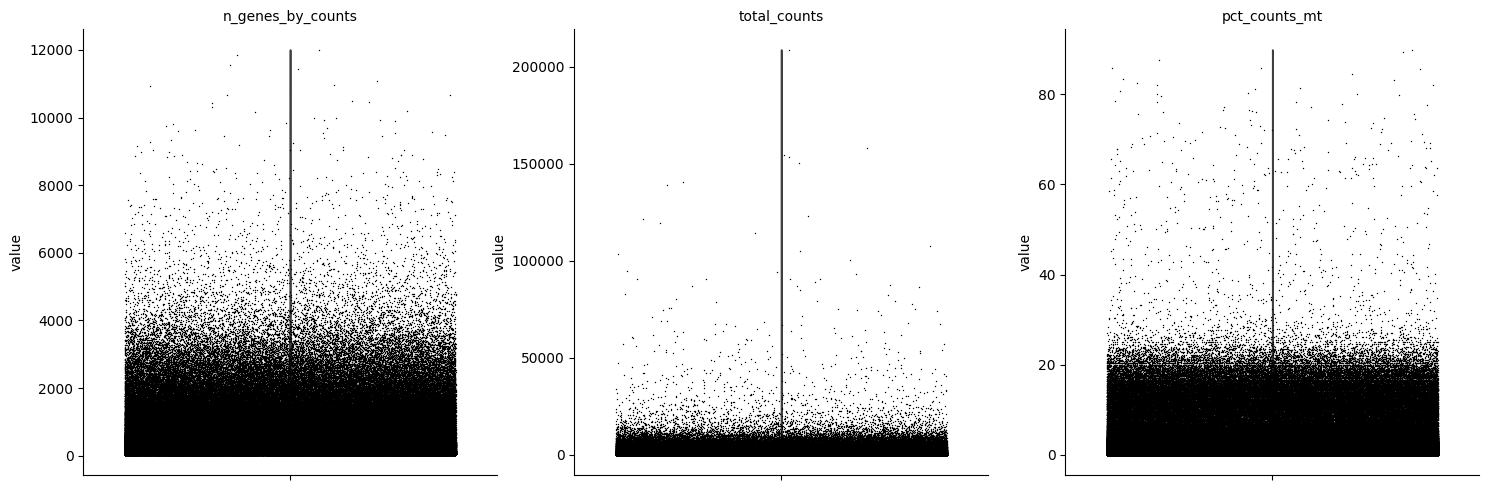

In [7]:
adata.var_names_make_unique()
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

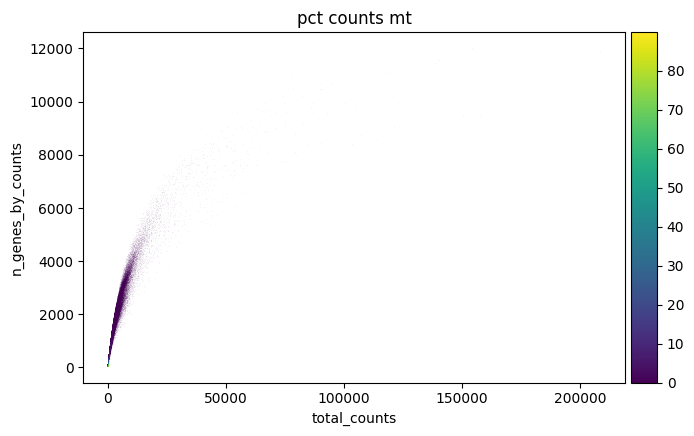

In [8]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [9]:
raw = adata.copy()

In [10]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

In [13]:
sc.pp.scrublet(adata,batch_key="sample")

/home/Data_Drive_8TB/kykim/.local/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))
/home/Data_Drive_8TB/kykim/.local/lib/python3.10/site-packages/scanpy/preprocessing/_scrublet/__init__.py:266: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  scrubbed_obs = pd.concat([scrub["obs"] for scrub in scrubbed])


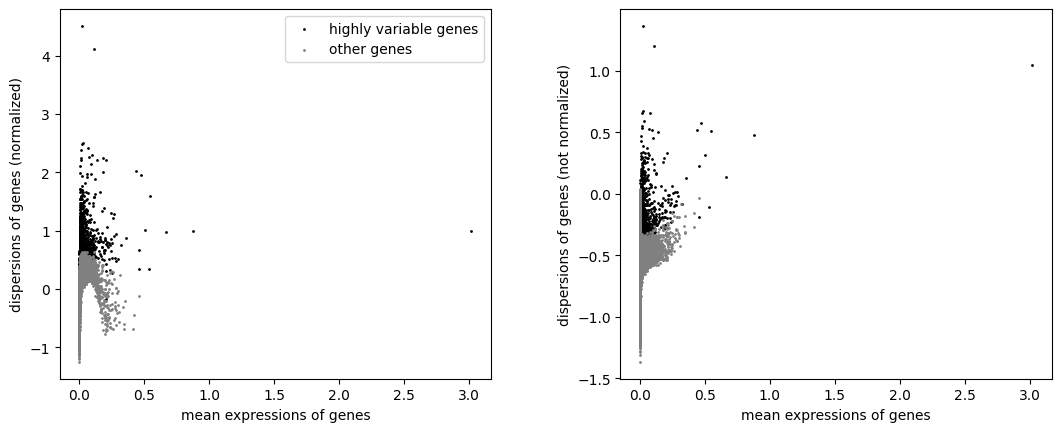

In [14]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample")
sc.pl.highly_variable_genes(adata)
adata = adata[:, adata.var['highly_variable']]

/home/Data_Drive_8TB/kykim/.local/lib/python3.10/site-packages/scanpy/preprocessing/_pca.py:314: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca


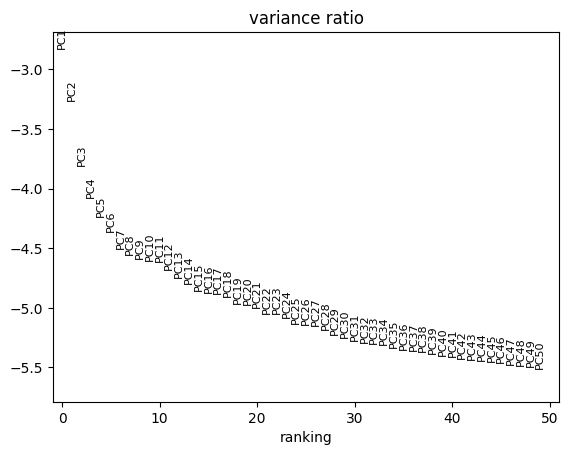

In [15]:
sc.tl.pca(adata)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

In [17]:
import scanpy.external as sce

sce.pp.bbknn(adata, batch_key='sample')
sc.pp.neighbors(adata)
sc.tl.umap(adata)

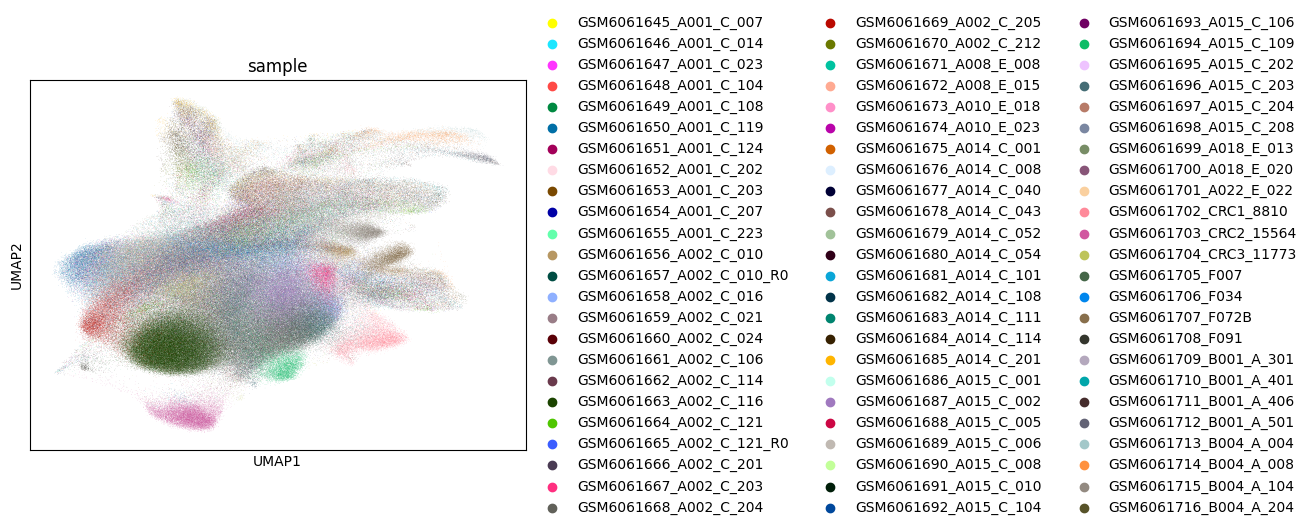

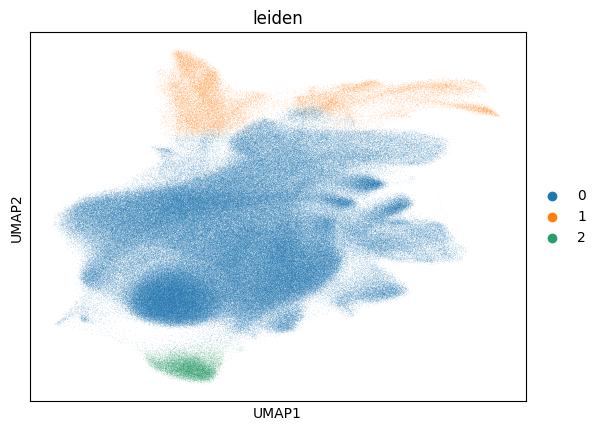

In [30]:
sc.tl.leiden(adata, flavor="igraph", n_iterations=2,resolution=0.10)
sc.pl.umap(adata,color=['sample'])
sc.pl.umap(adata,color=['leiden'])

In [ ]:
import celltypist

predictions = celltypist.annotate(adata, model = 'Human_Colorectal_Cancer.pkl', majority_voting = True)
adata = predictions.to_adata()
sc.pl.umap(Xadata, color = ['predicted_labels'])

⚠️ Warning: invalid expression matrix, expect ALL genes and log1p normalized expression to 10000 counts per cell. The prediction result may not be accurate
🔬 Input data has 563477 cells and 2000 genes
🔗 Matching reference genes in the model
🧬 1057 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 30


In [35]:
adata.obs['predicted_labels'].value_counts()

predicted_labels
Unknown                      395599
CMS2                         161759
CD19+CD20+ B                   4715
IgA+ Plasma                    1051
Enteric glial cells             277
Lymphatic ECs                    26
CMS1                             21
NK cells                         11
CMS3                              6
Stromal 3                         6
Stromal 2                         4
Mature Enterocytes type 2         1
Pericytes                         1
Name: count, dtype: int64

Cluster 0: ['SYTL2', 'PTPRN2', 'KCNMA1', 'NEDD4L', 'BCAS1', 'FCGBP', 'MUC2', 'MYRIP', 'CLCA1', 'TPM1', 'CRACR2A', 'PLXDC2', 'MUC4', 'ITPR2', 'PRKG1']
Cluster 1: ['RASGEF1B', 'FP671120.1', 'INO80D', 'SLC26A3', 'SLC27A6', 'PGGHG', 'CSMD1', 'COL19A1', 'PVT1', 'HSP90AA1', 'HSPB1', 'NOX1', 'AC069277.1', 'CCDC88B', 'IL17RB']
Cluster 2: ['RASGEF1B', 'INO80D', 'IGHA1', 'SLC26A3', 'MALAT1', 'SLC27A6', 'CSMD1', 'SLC26A2', 'SELENBP1', 'SLC30A10', 'MT-CO1', 'CKB', 'MT-ND3', 'ELF3', 'ADAMTSL1']
Cluster 3: ['MT-CO1', 'MT-CO2', 'MT-CO3', 'MT-ND4', 'MT-ND3', 'MT-ATP6', 'MT-ND2', 'MTRNR2L12', 'MT-CYB', 'MT-ND1', 'AC105402.3', 'DHFR', 'MT-ND5', 'MTRNR2L8', 'MT-ND4L']
Cluster 4: ['MALAT1', 'NEAT1', 'DST', 'TCF7L2', 'HHLA2', 'PCSK5', 'CEACAM1', 'SLC26A3', 'SLC26A2', 'MS4A12', 'PDE3A', 'GDA', 'PDE9A', 'SLC4A4', 'TRPM6']
Cluster 5: ['MT-CO1', 'SLC26A2', 'PIGR', 'CLCA4', 'PHGR1', 'ACTB', 'GUCA2A', 'KRT19', 'CD24', 'B2M', 'TMSB4X', 'FTH1', 'AC243967.1', 'MTRNR2L8', 'PDE3A']
Cluster 6: ['ADAMTSL1', 'PDE3A', 'R

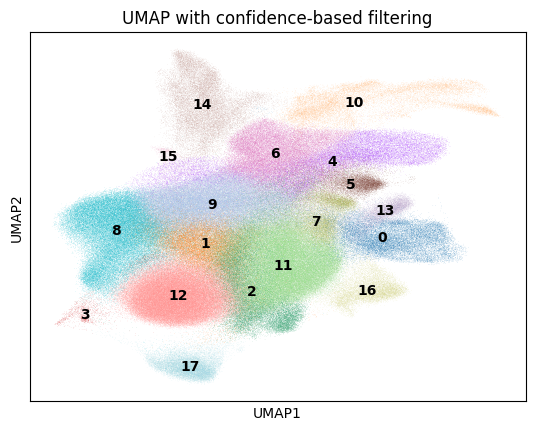

In [24]:
import scanpy as sc
sc.tl.rank_genes_groups(adata, groupby='leiden', method='t-test')  # 또는 'wilcoxon'
# 각 클러스터별 상위 10개 유전자 추출
top_genes = {}

groups = adata.uns['rank_genes_groups']['names'].dtype.names  # 클러스터 이름들

for group in groups:
    genes = adata.uns['rank_genes_groups']['names'][group][:15]
    top_genes[group] = genes.tolist()

# 결과 확인
for cluster, genes in top_genes.items():
    print(f"Cluster {cluster}: {genes}")
sc.pl.umap(
    adata,
    color='leiden',
    title='UMAP with confidence-based filtering',
    legend_loc='on data'  # 또는 'right margin', 'none'
)
